# Visita in Profondità (DFS).

## Esercizio sulla DFS
Sviluppa un algoritmo che, dato un grafo G tramite
liste di adiacenza ed un nodo sorgente s, restituisce la lista
dei nodi raggiunti a partire da s dalla visita DFS, nell’ordine in cui sono
stati visitati, in tempo \begin{equation} O(n + m) \end{equation}

C:\Users\potta\algoritmi_2\.venv\Lib\site-packages\networkx\drawing\nx_pylab.py:1353: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)


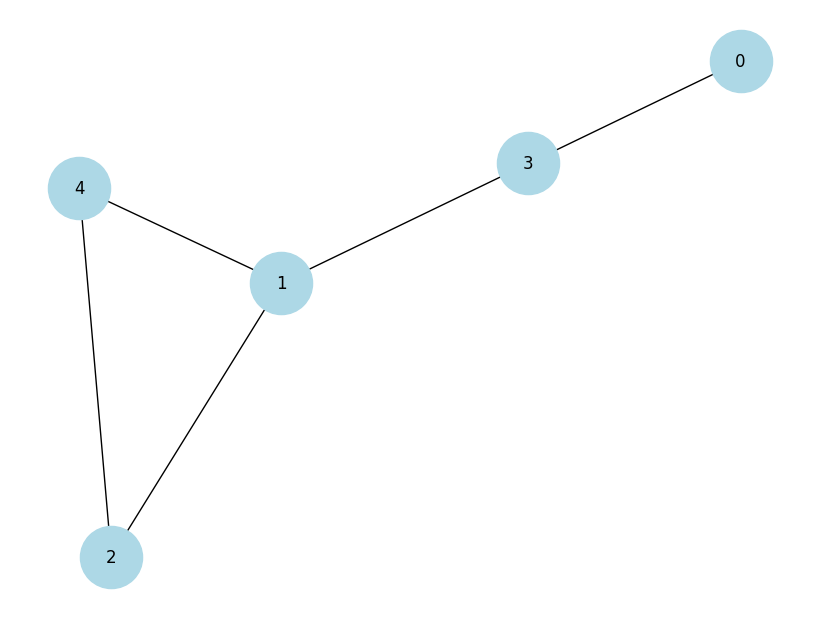

[1, 4, 2, 3, 0]


In [1]:
from Algoritmi2 import grafoLista

def DFS_es1(G, s):
    G.plot()
    da_visitare = [s]
    visitati = set()
    lista = []
    while da_visitare:
        elemento = da_visitare.pop()
        if elemento not in visitati:
            for vicino in G[elemento]:
                da_visitare.append(vicino)
            visitati.add(elemento)
            lista.append(elemento)
    return lista

print(DFS_es1(grafoLista.casuale(5), 1))


## Centri e Cammini in un Albero.

  ### Definizione: In un grafo connesso G l’eccentricità di un nodo è la sua massima distanza da tutti gli altri nodi del grafo.
   ### Definizione: Un nodo di G è un centro se ha l’eccentricità minima.

1. Dimostra che esistono grafi in cui tutti i nodi sono centri.
 2. Fornisci un esempio di un albero G che ha esattamente un solo centro.
3. Fornisci un esempio di un albero G che ha esattamente due centri.
4. Sia P un cammino di lunghezza massima in un albero G. Dimostra che i centri di G appartengono a questo cammino P.
5. Dimostra che un albero non può avere 3 centri.
6. Sviluppa un algoritmo che, dato un albero G di n nodi rappresentato
con liste di adiacenza, trova i centri di G n tempo \begin{equation} O(n^2)\end{equation}
7. Sviluppa un algoritmo più efficiente che, dato un albero G di n nodi
rappresentato con liste di adiacenza, trova i centri di G in tempo \begin{equation} O(n)\end{equation}

### 1. il grafo generato da: \$[[1],[0]]\$ ha due nodi ed entrambi sono centri.
### 2. l'albero generato da: \$[[1],[0,2],[1]]\$ ha un solo centro.
### 3. il grafo in risposta ad 1\. gode della proprietà richiesta
### 4. ???
### 5. ???

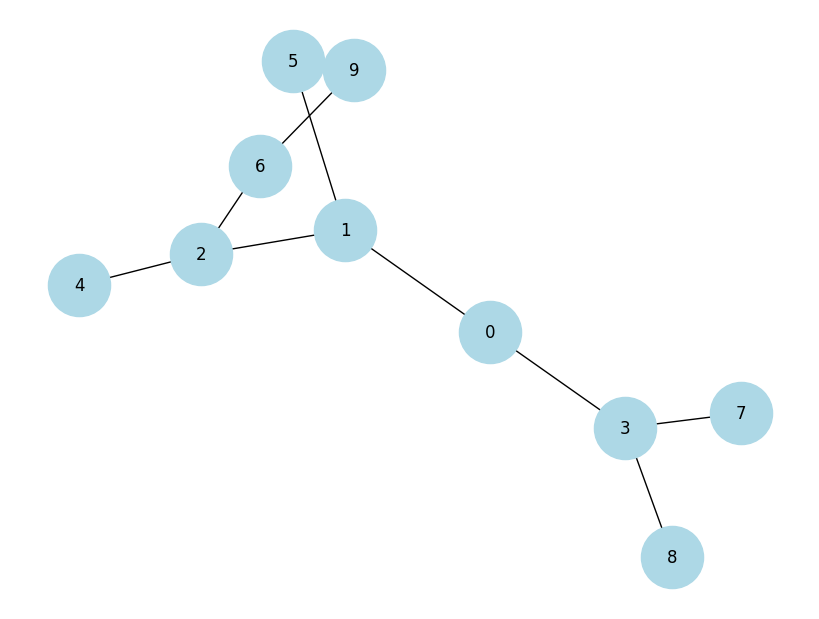

[1]


In [2]:
from Algoritmi2 import alberoListeAdiacenza

def supp1_n2_es2(A, root):
    vettore_distanze = [-1 for _ in range(len(A))]
    da_visitare = [root]
    vettore_distanze[root] = 0
    while da_visitare:
        elemento = da_visitare.pop()
        for vicino in A[elemento]:
            if vettore_distanze[vicino] == -1:
                vettore_distanze[vicino] = vettore_distanze[elemento] + 1
                da_visitare.append(vicino)
    return vettore_distanze

def n2_es2(A):
    A.plot()
    eccentricita = [float("inf") for _ in range(len(A))]
    for nodo in range(len(A)):
        ecc = max(supp1_n2_es2(A, nodo))
        eccentricita[nodo] = ecc
    to_return = []
    for n, e in enumerate(eccentricita):
        if not to_return or e < eccentricita[to_return[0]]:
            to_return = [n]
        elif e == eccentricita[to_return[0]]:
            to_return.append(n)

    return to_return

print(n2_es2(alberoListeAdiacenza.casuale(10)))


In [3]:
def punto_fisso(v, min = None, max = None):
    if min == None and max == None:
        min, max = 0, len(v)
    if min >= max:
        return False
    n = (min + max) // 2
    if v[n] == n:
        return True
    elif v[n] > n:
        return punto_fisso(v, min, n)
    else:
        return punto_fisso(v, n + 1, max)


v = [-4, -3,5,6,7,8]
print(punto_fisso(v))

False


In [4]:
def esercizio1(n, a_count = 0, b_count = 0, sol = None):
    if sol == None:
        sol = []
    if len(sol) == n:
        print("".join(sol))
    else:
        for x in {"a", "b"}:
            a_count += (x == "a")
            b_count += (x == "b")
            # devo imporre che a >= 2b
            # n = a + b
            # n <= 3a/2
            needed_a = max(0, 2*b_count - a_count + 1)
            if  needed_a <= n - len(sol) - 1:
                sol.append(x)
                esercizio1(n, a_count, b_count, sol)
                sol.pop()


esercizio1(5)

aaaaa
aaaab
aaaba
aaabb
aabaa
aabab
aabba
abaaa
abaab
ababa
abbaa
baaaa
baaab
baaba
babaa
bbaaa


In [5]:
def esercizio2(n, a_block_length = 0, sol = None):
    if sol is None:
        sol = []
    if len(sol) == n:
        print("".join(sol))
    else:
        for x in {"a", "b"}:
            remaining = n - len(sol) - 1
            if a_block_length % 2 == 0:
                if remaining > 0:
                    sol.append(x)
                    esercizio2(n, a_block_length + 1 * (x == "a"), sol)
                    sol.pop()
                elif x == "b":
                    sol.append(x)
                    esercizio2(n, a_block_length + 1, sol)
                    sol.pop()
            else:
                if x == "a":
                    sol.append(x)
                    esercizio2(n, a_block_length + 1, sol)
                    sol.pop()

esercizio2(10)

aaaaaaaaaa
aaaaaaaabb
aaaaaabaab
aaaaaabbaa
aaaaaabbbb
aaaabaaaab
aaaabaabaa
aaaabaabbb
aaaabbaaaa
aaaabbaabb
aaaabbbaab
aaaabbbbaa
aaaabbbbbb
aabaaaaaab
aabaaaabaa
aabaaaabbb
aabaabaaaa
aabaabaabb
aabaabbaab
aabaabbbaa
aabaabbbbb
aabbaaaaaa
aabbaaaabb
aabbaabaab
aabbaabbaa
aabbaabbbb
aabbbaaaab
aabbbaabaa
aabbbaabbb
aabbbbaaaa
aabbbbaabb
aabbbbbaab
aabbbbbbaa
aabbbbbbbb
baaaaaaaab
baaaaaabaa
baaaaaabbb
baaaabaaaa
baaaabaabb
baaaabbaab
baaaabbbaa
baaaabbbbb
baabaaaaaa
baabaaaabb
baabaabaab
baabaabbaa
baabaabbbb
baabbaaaab
baabbaabaa
baabbaabbb
baabbbaaaa
baabbbaabb
baabbbbaab
baabbbbbaa
baabbbbbbb
bbaaaaaaaa
bbaaaaaabb
bbaaaabaab
bbaaaabbaa
bbaaaabbbb
bbaabaaaab
bbaabaabaa
bbaabaabbb
bbaabbaaaa
bbaabbaabb
bbaabbbaab
bbaabbbbaa
bbaabbbbbb
bbbaaaaaab
bbbaaaabaa
bbbaaaabbb
bbbaabaaaa
bbbaabaabb
bbbaabbaab
bbbaabbbaa
bbbaabbbbb
bbbbaaaaaa
bbbbaaaabb
bbbbaabaab
bbbbaabbaa
bbbbaabbbb
bbbbbaaaab
bbbbbaabaa
bbbbbaabbb
bbbbbbaaaa
bbbbbbaabb
bbbbbbbaab
bbbbbbbbaa
bbbbbbbbbb


In [18]:
def esercizio3(n, sol = None, i = 0):
    if sol is None:
        sol = [None for _ in range(n)]
    if i >= n//2:
        print("".join(sol))
        return
    for x in {"a", "b"}:
        sol[i] = x
        sol[n-i-1] = x
        esercizio3(n, sol, i+ 1)

esercizio3(10)

aaaaaaaaaa
aaaabbaaaa
aaabaabaaa
aaabbbbaaa
aabaaaabaa
aababbabaa
aabbaabbaa
aabbbbbbaa
abaaaaaaba
abaabbaaba
ababaababa
ababbbbaba
abbaaaabba
abbabbabba
abbbaabbba
abbbbbbbba
baaaaaaaab
baaabbaaab
baabaabaab
baabbbbaab
babaaaabab
bababbabab
babbaabbab
babbbbbbab
bbaaaaaabb
bbaabbaabb
bbabaababb
bbabbbbabb
bbbaaaabbb
bbbabbabbb
bbbbaabbbb
bbbbbbbbbb


In [15]:
def pila_gettoni_mosse(n, a, b, c):
    # ogni gamestate può portare alla vittoria o di p1, o di p2,
    # o di entrambi se le possibilità sono varie. basta registrarle così.
    T = [None for _ in range(n+1)]
    T[0] = []
    for i in range(1, n+1): # O(n)
        temp = []
        if (i >= a and T[i-a]) or (i >= b and T[i-b]) or (i >= c and T[i-c]): #O(1)
            T[i] = True
        else:
            T[i] = False
    return T

def pila_gettoni_mosse_rice(n, a, b, c, T):
    if T[n] is None:
        player = 1 if turn % 2 == 1 else 2
        if n == a or n == b or n == c:
            if player == 2:
                T[n] = False
            else:
                T[n] = True
        if n < a and n < b and n < c:
            if player == 2:
                T[n] = True
            else:
                T[n] = False
        else:
            move_a, move_b, move_c = False, False, False
            if n > a:
               move_a = pila_gettoni_mosse_rice(n - a, a, b, c, T, turn + 1)
            if n > b:
                move_b = pila_gettoni_mosse_rice(n - b, a, b, c, T, turn + 1)
            if n > c:
                move_c = pila_gettoni_mosse_rice(n - c, a, b, c, T, turn + 1)
            if move_a or move_b or move_c:
                T[n] = True
            else:
                T[n] = False
    return T[n]

def pila_gettoni(n, a, b, c):
    T = [None for i in range(n+1)]
    return pila_gettoni_mosse_rice(n, a, b, c, T, 1)


from Algoritmi2 import alberoListeAdiacenza

def pila_gettoni_albero(n, a, b, c):
    T = []
    for i in range(n+1):
        temp = []
        if a <= i:
            temp.append(i-a)
        if b <= i:
            temp.append(i-b)
        if c <= i:
            temp.append(i-c)
        T.append(temp)
    # così in T ora ho la possibilità di sapere ogni volta quali sono i possibili stati a cui mi riconduco
    return T

def esplora_albero(n, a, b, c):
    # ogni gamestate può portare alla vittoria o di 0, o di 1, o di entrambi se le possibilità sono varie. basta registrarle così.
    pass

print(pila_gettoni(5, 1, 2, 3))

#print(pila_gettoni_g(5, 1, 3, 4))

False


In [11]:
def numero_sequenze_nondecrescenti(n):
    """
    T è una tabella 10 x n
    dove ogni riga contiene quante sono le sequenze di numeri decimali non decrescenti che iniziano con il numero di colonna.
    per n = 2
    [1,1,1,1,1,1,1,1,1,1]
    [10,9,8,7,6,5,4,3,2,1]
    [
    poi 0 aumenta di tutti i numeri minori di 0
    """
    T = [[0 for _ in range(10)] for _ in range(n+1)]
    T[0], T[1] = [0 for _ in range(10)], [1 for _ in range(10)]
    for i in range(2, n+1):
        for j in range(0, 10):
            T[i][j] = sum(T[i-1][k] for k in range(j, 10))
    return sum(T[n]), T

print(numero_sequenze_nondecrescenti(3))


(220, [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [10, 9, 8, 7, 6, 5, 4, 3, 2, 1], [55, 45, 36, 28, 21, 15, 10, 6, 3, 1]])
